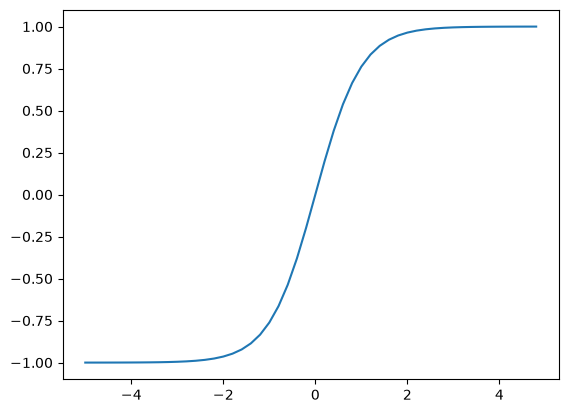

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)));
plt.show()

In [2]:
plt.show()

In [ ]:
class Value:
    def __init__(self, data, _children = (), _op= '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda : None
        self.grad = 0
        self.label = label
    
    def __repr__(self):
        return f"Value(data = {self.data})"
    

    #Gradients need to be accumulated, as if not, when you use a variable more than once, the gradients become
    # incorrect.
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data*other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n)-1)/(math.exp(2*n)+1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad = (1-t**2)*out.grad
        out._backward = _backward
        return out
    
    #Implemented a backward function using topological sort, that runs the ._backward() function attribute of 
    # an object in reverse topological order, so as to propagate the gradient values correctly.
    
    def backward(self):
        topo =[]
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
            topo.append(v)
        build_topo(self) 
        self.grad = 1.0
        topo.reverse()
        for num in topo:
            num._backward()

In [ ]:
from graphviz import Digraph

#Digraph library, used for representing neural nets.
#First function is a simple graph building function, the second one uses nodes, as data-points and 

def trace(root):
    """Walk the graph backward from `root`, collecting every node and edge."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format='svg', rankdir='LR'):
    """
    Render the computation graph rooted at `root`.
    format:  'svg' | 'png' | ...   (svg is crisp in notebooks)
    rankdir: 'LR' (left-to-right) | 'TB' (top-to-bottom)
    """
    assert rankdir in ('LR', 'TB')
    nodes, edges = trace(root)

    dot = Digraph(
        format=format,
        graph_attr={'rankdir': rankdir},
    )

    for n in nodes:
        # each Value gets a rectangular "record" node showing label | data | grad
        dot.node(
            name=str(id(n)),
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record',
        )
        # if this Value was produced by an operation, add an op node and wire it in
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for n1, n2 in edges:
        # connect n1 to the op node that produced n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [ ]:
h = 0.0001

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = "x2")
w1 = Value(-3.0, label ="w1")
w2 = Value(1.0, label = "w2")
b = Value(6.8813735870195432, label = "b")
x1w1 = x1*w1; x1w1.label = "x1w1"
x2w2 = x2*w2;  x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1w1x2w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = 'o'


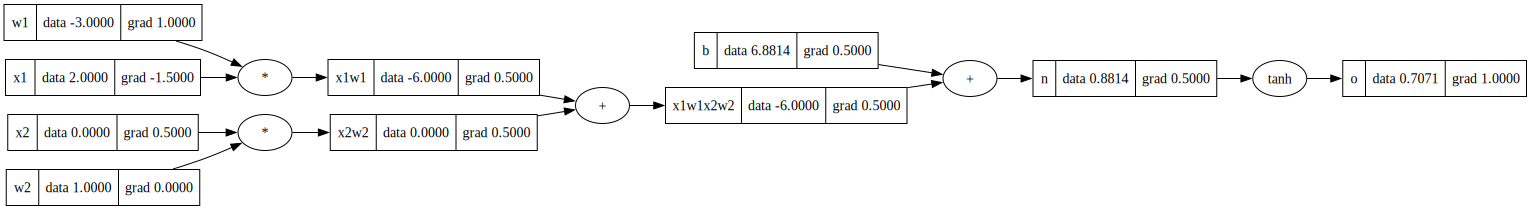

In [46]:
o.backward()
draw_dot(o)